In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import numpy as np
from PIL import Image
from pathlib import Path

In [2]:
CFG = {
    # Model
    "scale"       : 4,
    "dim"         : 48,
    "n_blocks"    : 6,
    "in_channels" : 3,
    "out_channels": 3,

    # Checkpoint
    "exp_dir"   : "experiments/span_df2k_optuna_x4_silu_mod"
}

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SPAB(nn.Module):
    def __init__(self, dim: int = 48):
        super().__init__()
        self.c1_r = nn.Conv2d(dim, dim, 3, 1, 1)
        self.c2_r = nn.Conv2d(dim, dim, 3, 1, 1)
        self.c3_r = nn.Conv2d(dim, dim, 3, 1, 1)
        self.act  = nn.SiLU(inplace=False)

    def forward(self, x):
        h = self.act(self.c1_r(x))
        h = self.act(self.c2_r(h))
        h = self.c3_r(h)
        sim_att = torch.sigmoid(h)
        return (h + x) * sim_att


class Upsampler(nn.Sequential):
    def __init__(self, scale, out_ch=3, dim=48):
        super().__init__(
            nn.Conv2d(dim, out_ch * scale * scale, 3, 1, 1),
            nn.PixelShuffle(scale),
        )


class SPAN(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, dim=48, n_blocks=6, scale=4):
        super().__init__()
        self.scale    = scale
        self.n_blocks = n_blocks

        self.conv_in  = nn.Conv2d(in_ch, dim, 3, 1, 1)
        self.blocks   = nn.ModuleList([SPAB(dim) for _ in range(n_blocks)])
        self.conv_2   = nn.Conv2d(dim, dim, 3, 1, 1)

        self.conv_cat = nn.Conv2d(dim * 4, dim, 1, 1, 0)
        self.up       = Upsampler(scale, out_ch=out_ch, dim=dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # FIX 1: lưu f0 riêng để dùng trong cat
        f0 = self.conv_in(x)

        f = f0
        outputs = []
        for block in self.blocks:
            f = block(f)
            outputs.append(f)

        # FIX 2: refine output cuối
        outputs[-1] = self.conv_2(outputs[-1])

        mid = self.n_blocks // 2
        cat = torch.cat([
            f0,
            outputs[0],
            outputs[mid],
            outputs[-1],
        ], dim=1)

        return self.up(self.conv_cat(cat))

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("SPAN defined")

SPAN defined


Saved SR image to: image_sr\lamp_SR.png


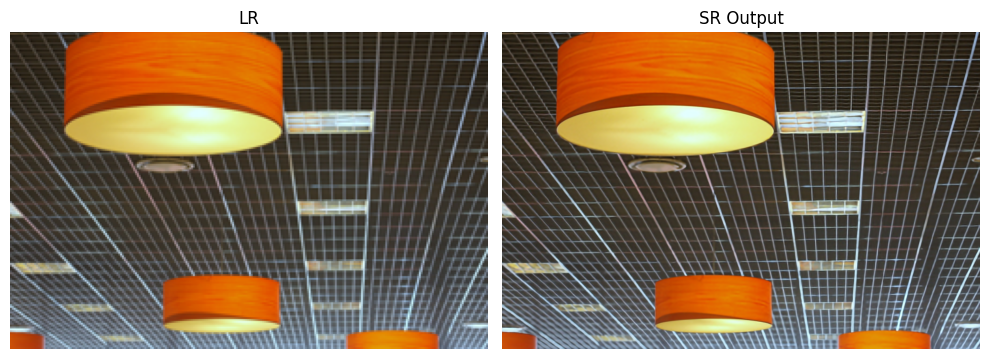

In [4]:
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = Path(CFG["exp_dir"]) / "checkpoints" / "best.pth"

# Đường dẫn ảnh
LR_PATH  = "image_test/lamp.png"
SAVE_DIR = "image_sr"



# Load model
if not CKPT_PATH.exists():
    print("Chua co best.pth")
else:
    model = SPAN(
        dim=CFG["dim"],
        n_blocks=CFG["n_blocks"],
        scale=CFG["scale"]
    ).to(DEVICE)

    ckpt = torch.load(str(CKPT_PATH), map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()

    # ===== load ảnh =====
    lr_pil = Image.open(LR_PATH).convert("RGB")
    lr_t = TF.to_tensor(lr_pil).unsqueeze(0).to(DEVICE)


    # ===== inference =====
    with torch.no_grad():
        sr_t = model(lr_t).clamp(0,1)

    # ===== convert SR → PIL =====
    sr_np = sr_t.squeeze().cpu().permute(1,2,0).numpy()
    sr_img = Image.fromarray((sr_np * 255.0).round().astype(np.uint8))

    # ===== save =====
    save_dir = Path(SAVE_DIR)
    save_dir.mkdir(parents=True, exist_ok=True)

    input_name = Path(LR_PATH).stem
    save_path = save_dir / f"{input_name}_SR.png"
    sr_img.save(save_path)

    print(f"Saved SR image to: {save_path}")

    # ===== show =====
    lr_np = TF.to_tensor(lr_pil).permute(1,2,0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10,5))

    axes[0].imshow(lr_np.clip(0,1))
    axes[0].set_title(f"LR")
    axes[0].axis("off")

    axes[1].imshow(sr_np.clip(0,1))
    axes[1].set_title(f"SR Output")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()